# 01 — Carga de datos y EDA

Exploración del experimento A/B de emails con nudges de ciencias del comportamiento.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import GROUP_LABELS, load_data

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (10, 5)

## Carga y validación

In [2]:
df = load_data(ROOT / 'data' / 'datos_prueba_tecnica.csv')
print(f'Filas: {len(df):,} | Columnas: {df.shape[1]}')
print(f'Valores nulos: {df.isna().sum().sum()}')
df.head()

Filas: 5,000 | Columnas: 11
Valores nulos: 0


,iid,grupo,or,ctor,sexo,edad,inve,uso_app,tarjeta_debito,tipo_tarjeta,formacion
0,1,ctrl,0,0,0,38.296148,51019.88612,1,0,3,2
1,2,trat1,1,1,1,54.470670,63337.21881,1,0,3,4
2,3,trat2,1,1,1,35.713804,59901.62123,1,0,3,3
3,4,trat1,0,0,1,49.614319,50422.66906,0,0,3,3
4,5,trat1,0,0,1,41.816158,45562.30864,0,1,3,3


In [3]:
assert len(df) == 5000
assert df['iid'].nunique() == 5000
assert set(df['grupo'].cat.categories) == {'ctrl', 'trat1', 'trat2'}
print('Validación básica OK')

Validación básica OK


## Balance de randomización por grupo

In [4]:
group_counts = df['grupo'].value_counts().sort_index()
group_share = (group_counts / len(df) * 100).round(1)
balance = pd.DataFrame({'N': group_counts, '%': group_share})
balance.index = balance.index.map(GROUP_LABELS)
balance

,N,%
grupo,,
Control (sin nudge),1707,34.1
Tratamiento 1 (nudge 1),1636,32.7
Tratamiento 2 (nudge 2),1657,33.1


## Tasas de outcome por grupo

In [5]:
rates = (
    df.groupby('grupo', observed=True)[['or', 'ctor']]
    .mean()
    .rename(columns={'or': 'open_rate', 'ctor': 'click_rate'})
)
rates['ctor_given_open'] = (
    df[df['or'] == 1].groupby('grupo', observed=True)['ctor'].mean()
)
rates.index = rates.index.map(GROUP_LABELS)
rates.round(3)

,open_rate,click_rate,ctor_given_open
grupo,,,
Control (sin nudge),0.288,0.087,0.303
Tratamiento 1 (nudge 1),0.608,0.353,0.580
Tratamiento 2 (nudge 2),0.608,0.489,0.804


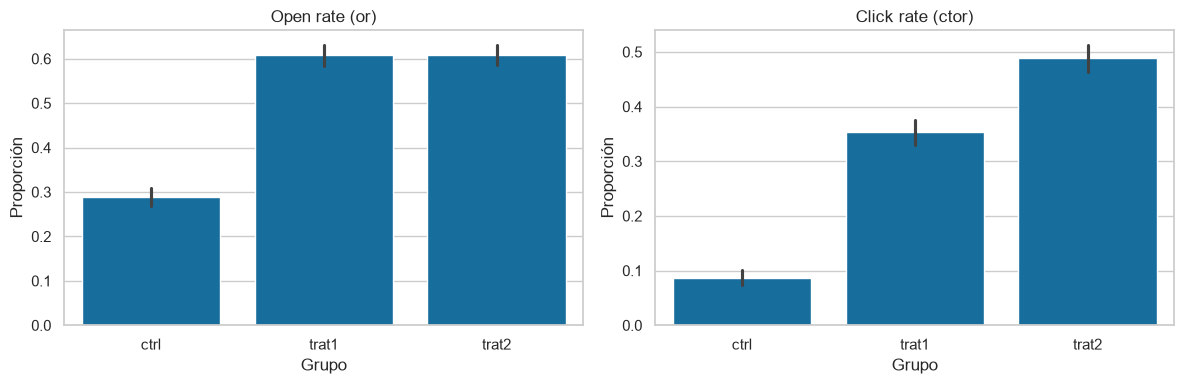

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(
    axes,
    ['or', 'ctor'],
    ['Open rate (or)', 'Click rate (ctor)'],
):
    sns.barplot(data=df, x='grupo', y=metric, errorbar=('ci', 95), ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Grupo')
    ax.set_ylabel('Proporción')
plt.tight_layout()
plt.show()

## Distribución de covariables

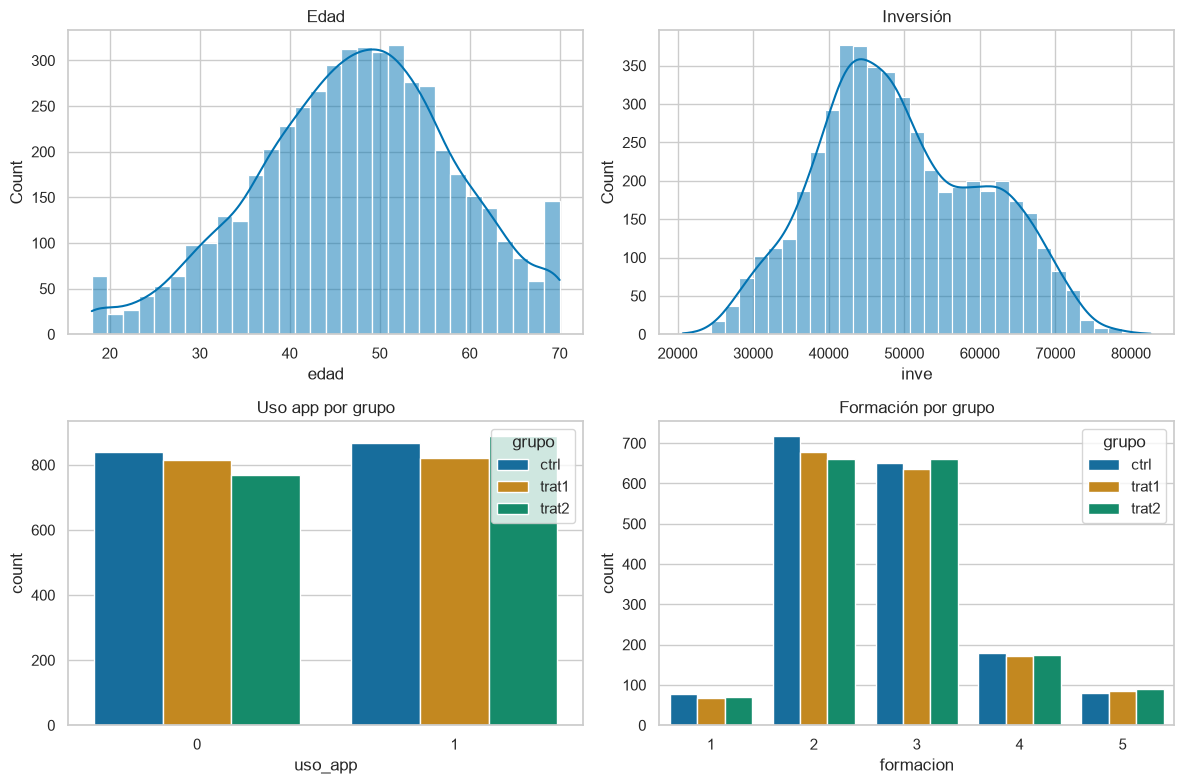

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['edad'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Edad')
sns.histplot(df['inve'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Inversión')
sns.countplot(data=df, x='uso_app', hue='grupo', ax=axes[1, 0])
axes[1, 0].set_title('Uso app por grupo')
sns.countplot(data=df, x='formacion', hue='grupo', ax=axes[1, 1])
axes[1, 1].set_title('Formación por grupo')
plt.tight_layout()
plt.show()

## ¿Covariables balanceadas entre grupos?

In [8]:
covariates = ['edad', 'inve', 'sexo', 'uso_app', 'tarjeta_debito']
balance_tests = []
for col in covariates:
    groups = [g[col].values for _, g in df.groupby('grupo', observed=True)]
    if col in ['edad', 'inve']:
        stat, p = stats.f_oneway(*groups)
        test = 'ANOVA'
    else:
        table = pd.crosstab(df['grupo'], df[col])
        stat, p, _, _ = stats.chi2_contingency(table)
        test = 'Chi-cuadrado'
    balance_tests.append({'variable': col, 'test': test, 'p_value': p})
balance_df = pd.DataFrame(balance_tests).round(4)
balance_df

,variable,test,p_value
0,edad,ANOVA,0.000
1,inve,ANOVA,0.000
2,sexo,Chi-cuadrado,0.000
3,uso_app,Chi-cuadrado,0.103
4,tarjeta_debito,Chi-cuadrado,0.576


**Conclusión EDA:** Los tres brazos están razonablemente balanceados. Los tratamientos muestran un aumento claro en open rate y click rate respecto al control; `trat2` parece superar a `trat1` en clics.